# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Load models

### Normal

In [2]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [3]:
model= mfl.MOFAFLEX.load(models_path / 'crc_232.hdf5')

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### SnS

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

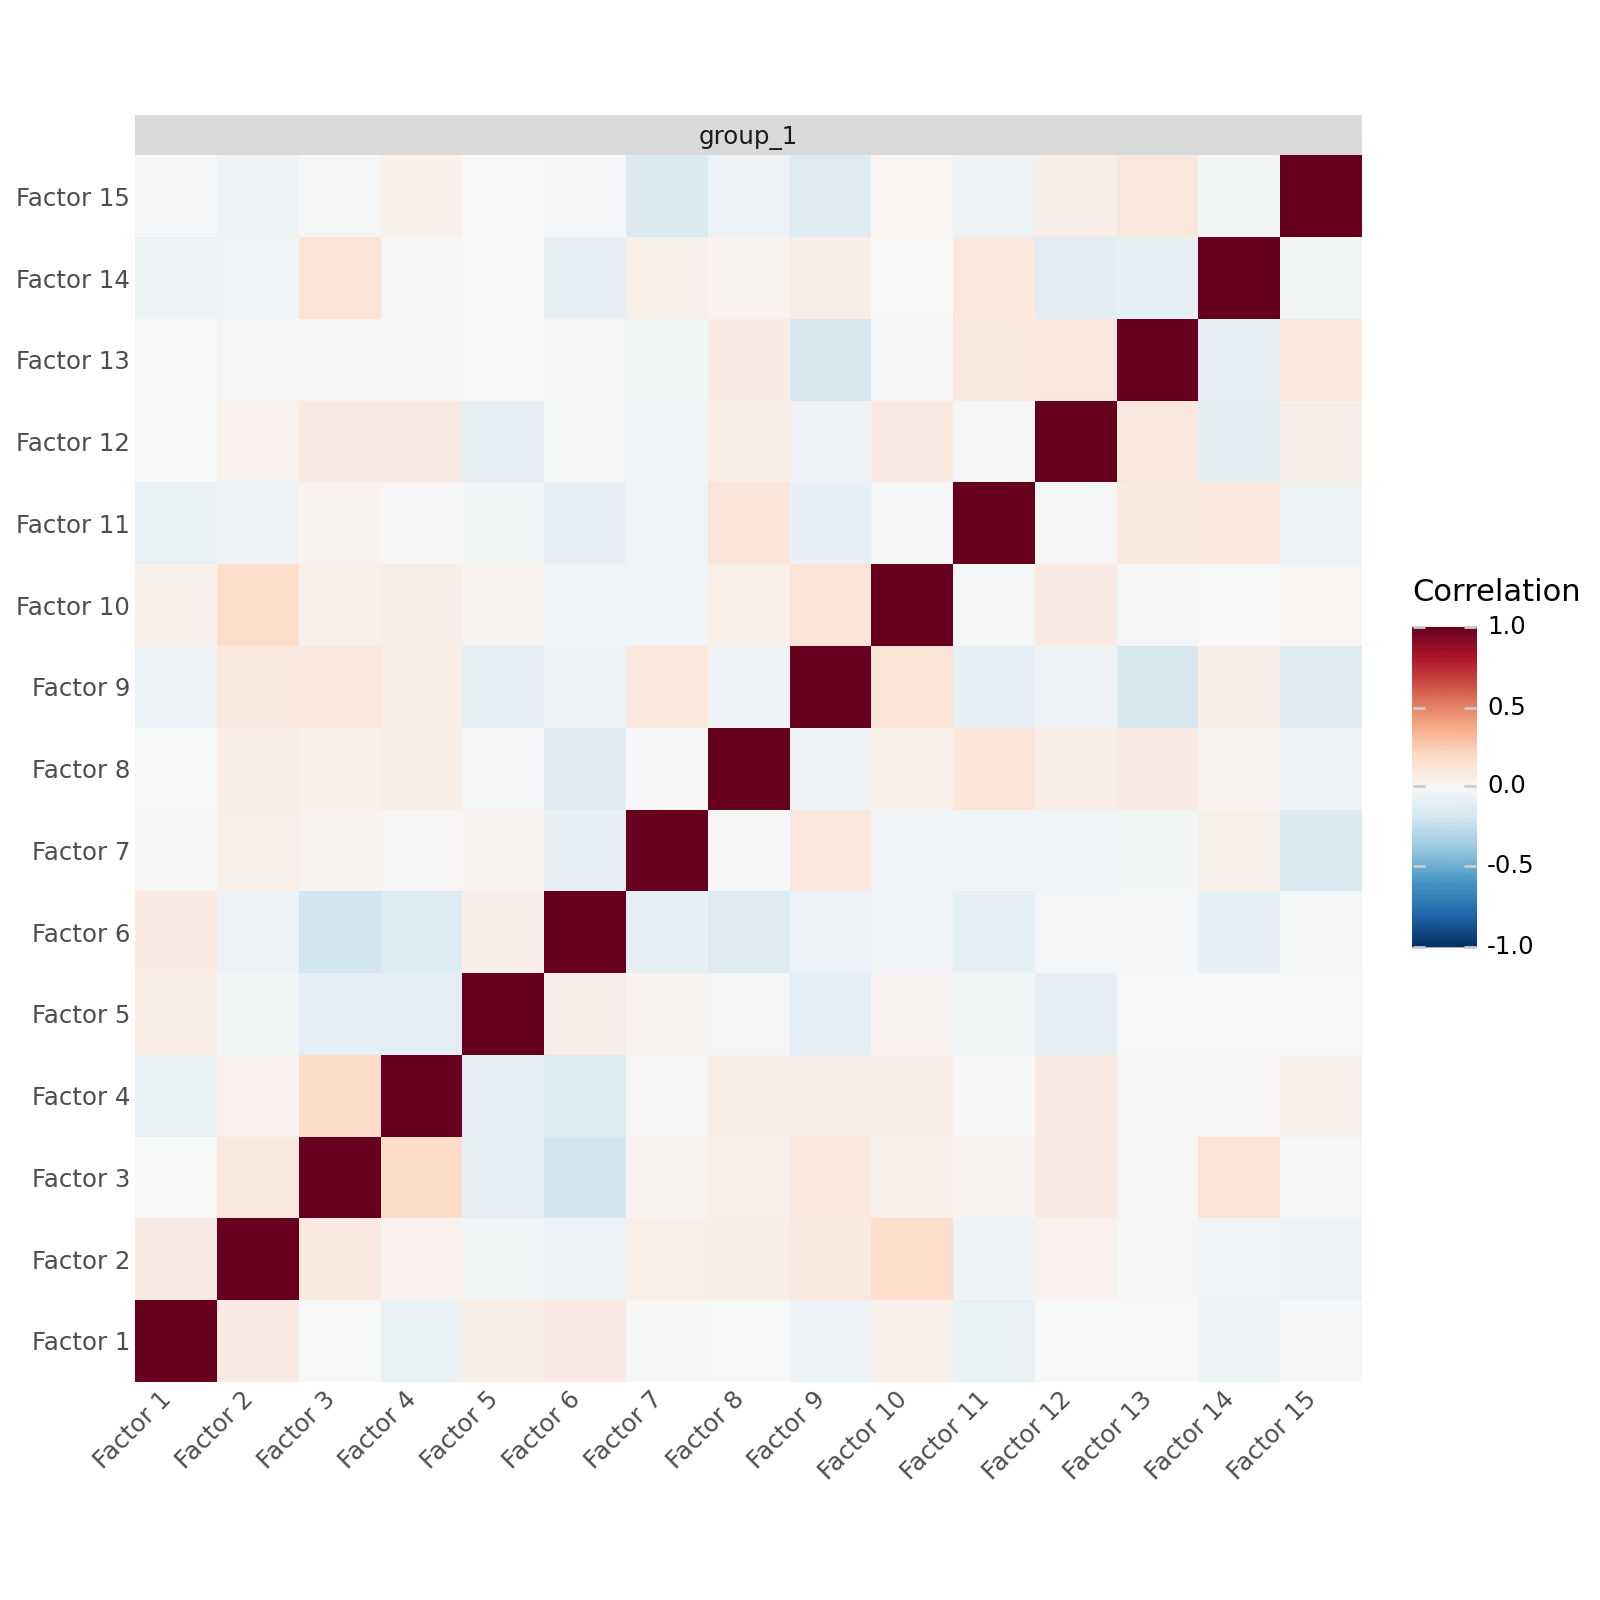

In [71]:
mfl.pl.factor_correlation(model)

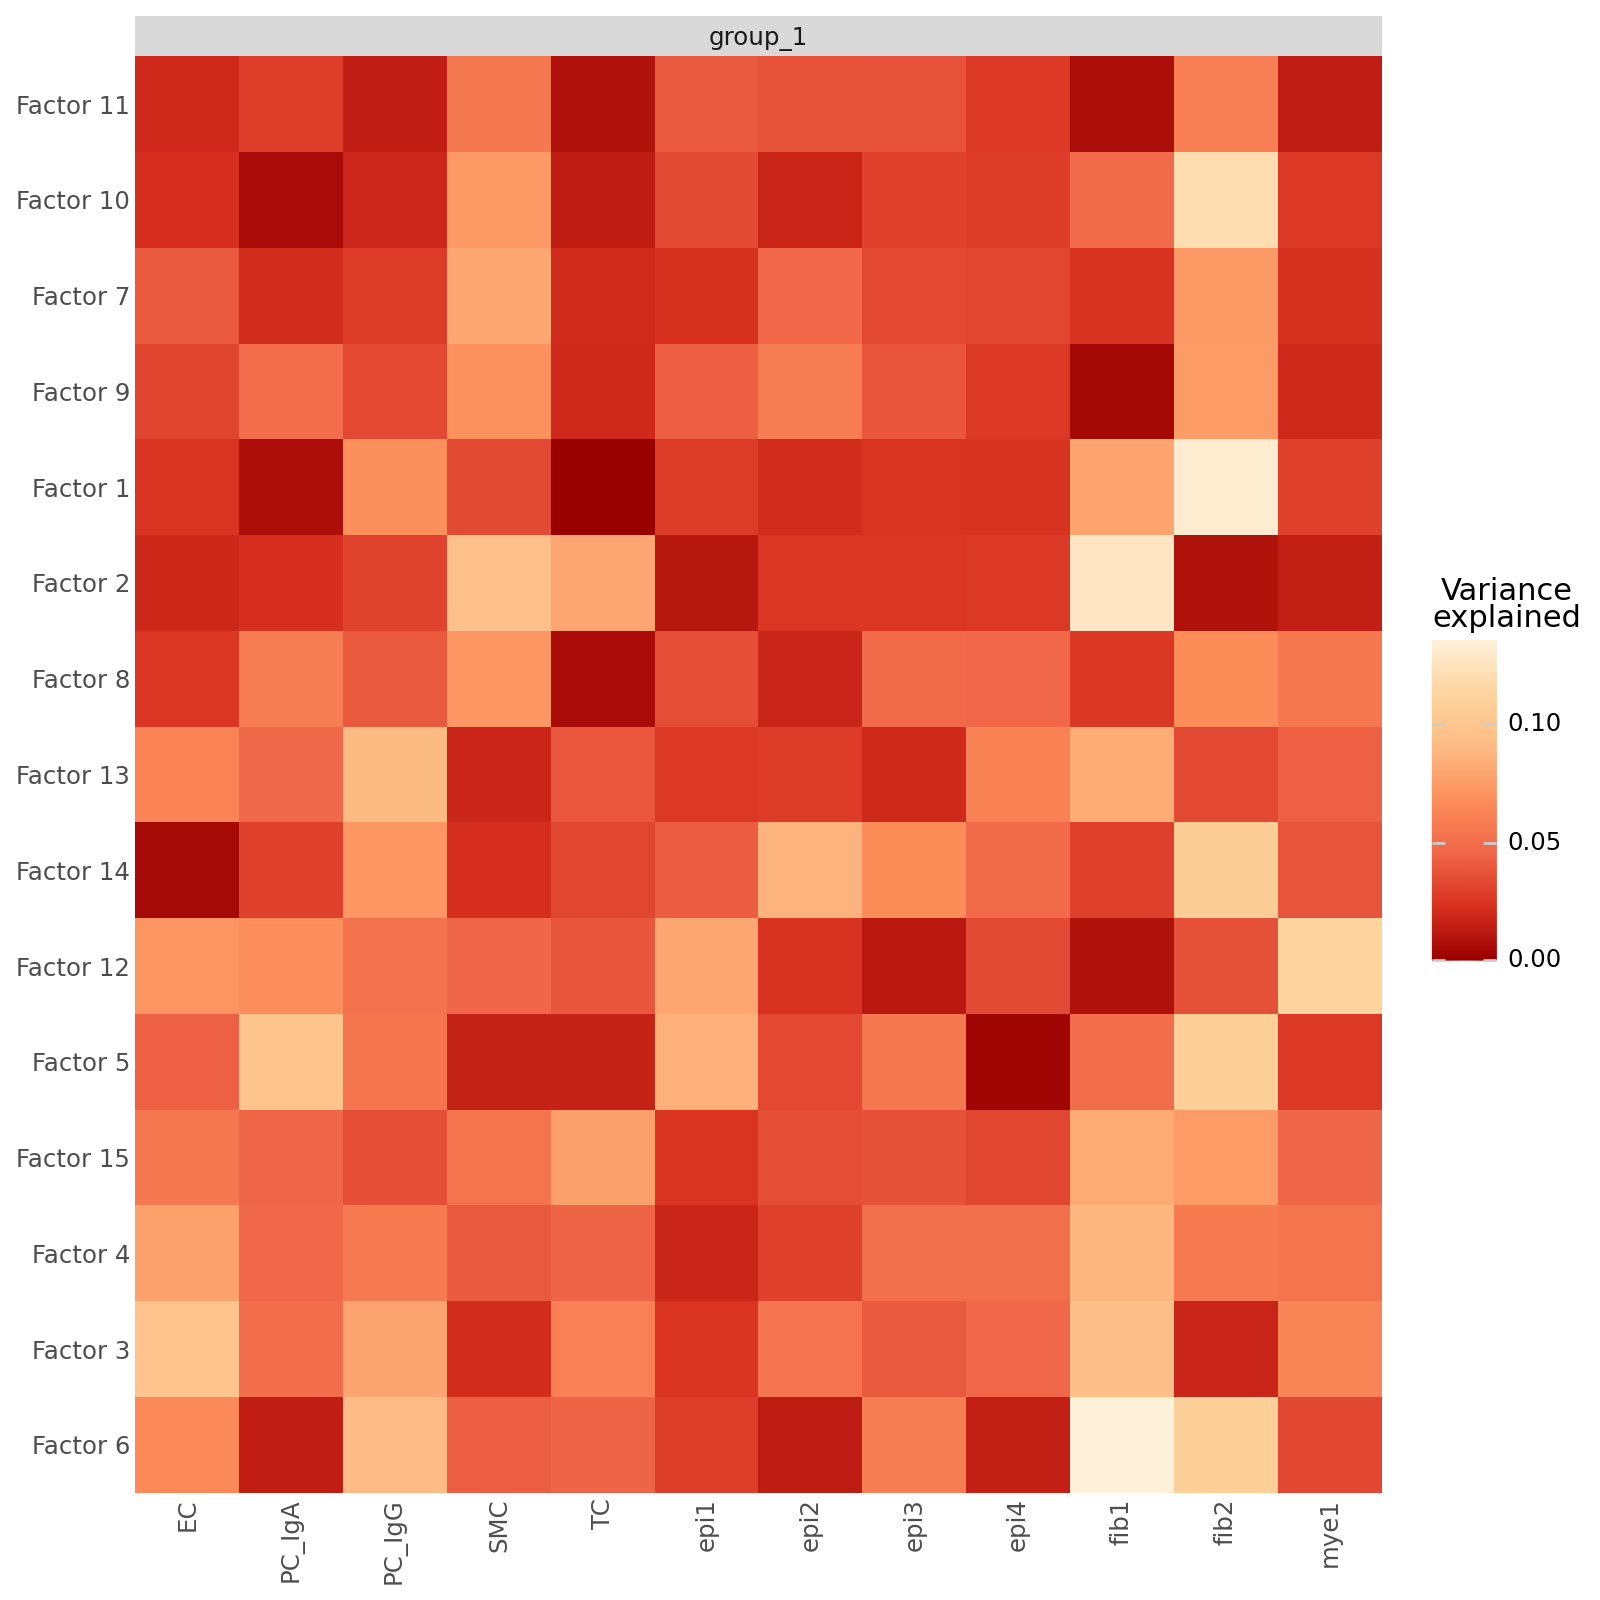

In [72]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [73]:
print(model.get_r2(total=True))

         group_1
epi4    0.525358
epi2    0.457083
epi1    0.517178
epi3    0.557948
mye1    0.571551
fib2    0.957233
EC      0.558809
TC      0.571345
SMC     0.808366
fib1    0.840767
PC_IgG  0.621116
PC_IgA  0.623549


In [74]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

0.6341917503642843

## 3.Weights dist

In [75]:
weights_dict= model.get_weights()

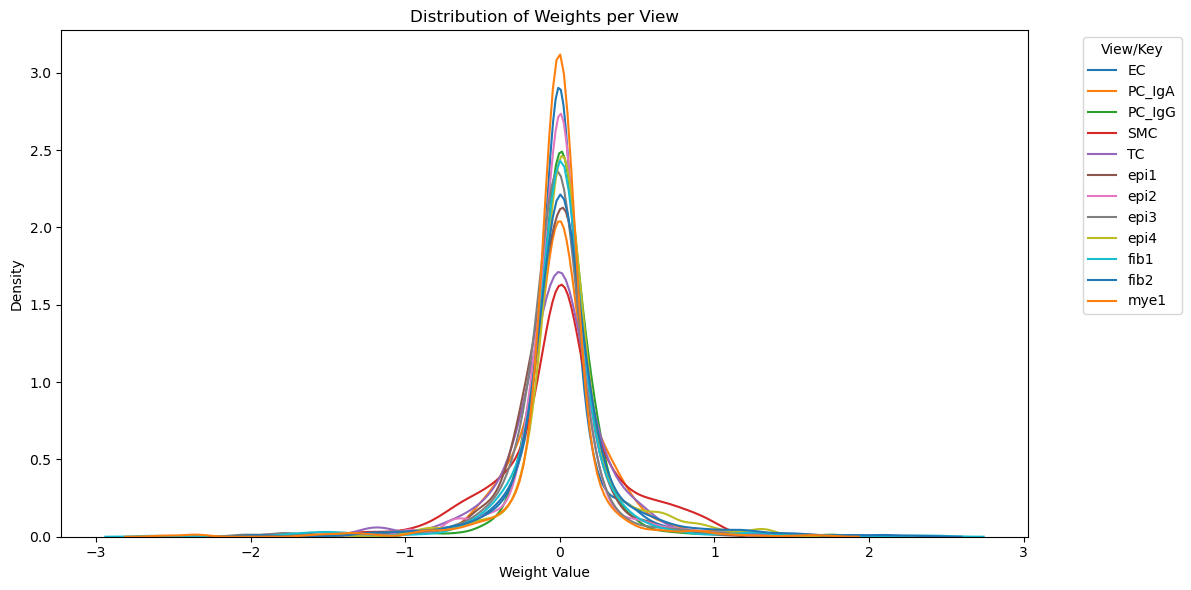

In [76]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [124]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [77]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [78]:
weights = model.get_weights()

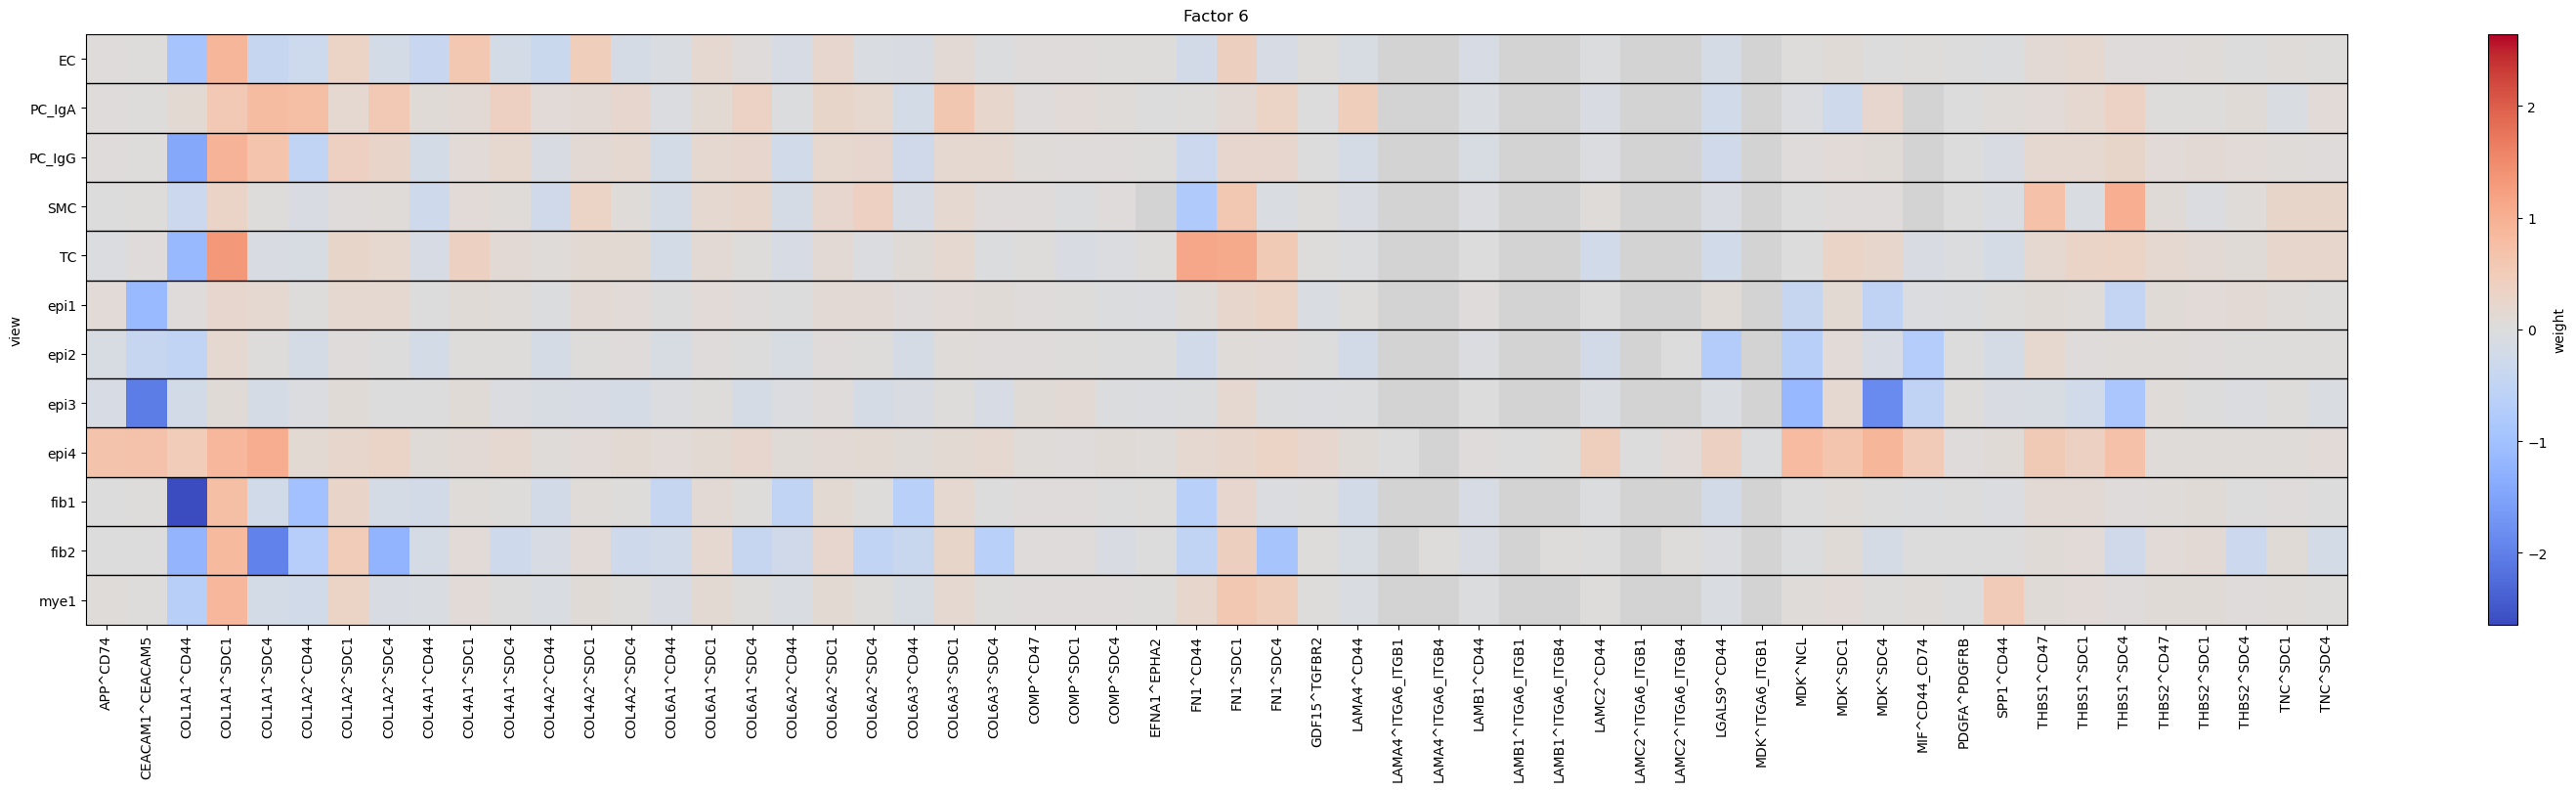

In [79]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 6

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [80]:
factors = model.get_factors()
factors = factors["group_1"]

In [81]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_154_37,0.132779,0.142480,0.975769,-0.556895,-0.927954,-0.384908,-0.020059,-0.587895,0.183824,-0.096323,-0.342487,-0.250388,-0.684398,1.148717,-0.270025
c_3_154_43,0.294566,0.008033,0.433853,-0.103059,-0.592117,0.132746,-0.211608,-0.366292,0.001529,1.140662,-0.245005,0.175639,-0.221797,0.418301,0.040954
c_3_154_61,-0.190235,-0.460681,0.565774,-0.294287,-0.051914,0.313991,-0.410119,-0.363320,0.337479,0.763851,0.259194,-0.365572,-0.298421,-0.287144,0.161366
c_3_154_69,-0.096173,-0.078650,-0.326810,0.341373,-0.325778,-0.193075,-0.247690,-0.048396,0.051235,0.656726,0.387509,-0.128258,0.342003,-0.051961,0.709008
c_3_154_75,-0.077283,0.222358,-0.242813,-0.222596,-0.340299,-0.375647,-0.651844,0.277687,0.352592,0.324416,0.108394,0.194084,0.450819,-0.154401,0.772074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_163_214,0.681667,-0.008299,0.193849,-0.670376,0.078092,-0.093796,-0.584809,0.224866,-0.228838,-0.318902,-0.881349,0.484895,-0.342769,0.137890,0.730775
c_3_163_1843,-0.849747,-0.998791,1.644473,-0.180919,-0.626920,0.791192,1.100312,-1.278113,-1.091323,0.057494,1.031343,1.674226,0.073975,0.513531,-0.487985
c_3_163_2575,0.903031,-0.958014,-0.743372,-0.516569,-0.043565,-0.020973,0.178430,0.401002,-1.188670,-0.269057,-0.206928,0.435796,-0.394546,-0.237796,-0.170495
c_3_164_158,-0.926580,-0.738160,-0.697822,0.337824,1.279668,0.226298,0.154370,-1.261031,-0.011495,-0.270136,0.051235,-0.908782,-0.556201,-0.780334,0.904580


### Load lrdata

In [6]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_232_lrdata.h5ad")

In [52]:
lv1 = lrdata.obs["lv1"]
lv2 = lrdata.obs["lv2"]
ist = lrdata.obs["ist"]
typ = lrdata.obs["typ"]

In [53]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(20377,)

## UMAP

In [54]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [55]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [11]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [12]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=6, noise=8.64%


#### 2D UMAP

In [15]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [56]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

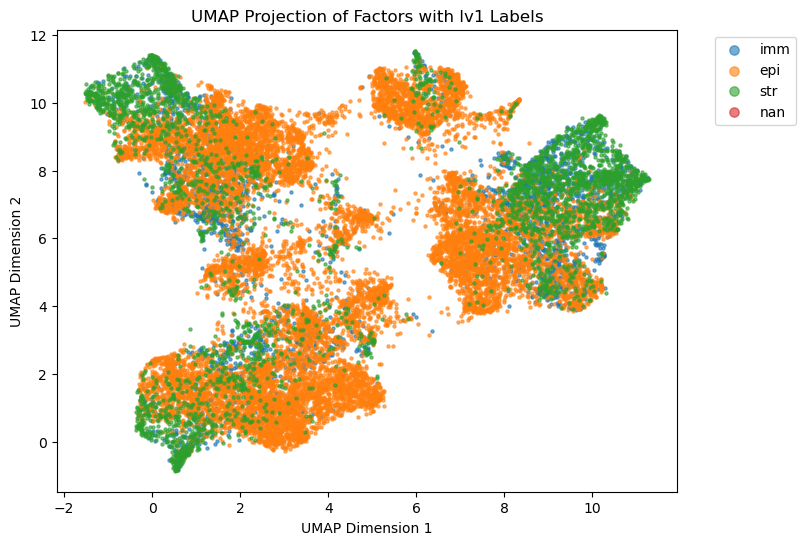

In [58]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

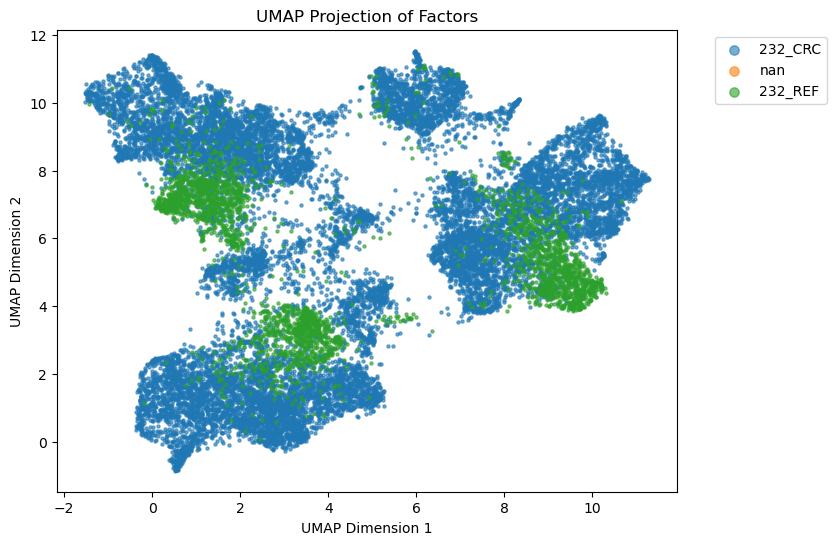

In [18]:
df_umap['Label'] = typ.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

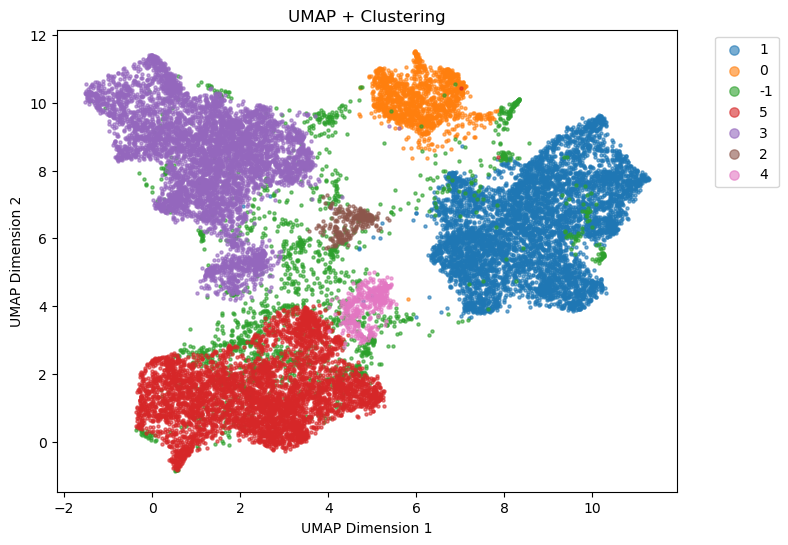

In [19]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Regression Model

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["lv1"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [22]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_147_106,-0.412813,-0.150046,0.031337,-0.669878,0.280432,0.926087,-0.865765,-0.947557,-0.006668,-0.876183,-0.651299,0.163320,0.323335,-0.734269,0.631571
c_3_147_69,-0.805857,0.899927,-0.034085,0.050897,-0.179051,-0.393218,0.739438,1.442779,-0.347786,-0.398321,-0.461636,-0.322945,-0.141259,-0.231288,0.234506
c_3_148_110,-0.496759,-0.751842,-0.208446,-0.391521,-0.925550,-0.370377,0.188301,0.480440,0.887331,-0.842113,-0.213995,-0.204917,-0.066395,0.004894,-0.760560
c_3_148_120,-0.917460,-1.030808,0.890663,-1.301286,-0.437118,1.192290,1.805100,-0.249767,-0.162787,-0.897038,0.651225,2.098300,0.078525,-0.091642,-2.131999
c_3_148_121,-1.058986,-0.407760,-0.339113,0.132662,0.082663,-0.983423,0.862038,-0.596215,-0.428028,1.266770,0.626280,1.137571,-1.239499,-0.086900,1.762639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_217_975,-0.559635,-0.167994,0.977480,1.115190,-0.310484,0.271506,0.219449,-0.789795,-0.988108,-0.284078,-0.162469,0.952176,0.972427,0.685399,0.512966
c_3_217_977,0.509102,0.336842,0.406287,0.668467,-0.368952,-0.161435,0.822598,0.139394,0.743262,0.144597,-0.601651,-0.560111,-0.751368,0.196739,-0.241314
c_3_217_979,0.548766,0.509910,0.369765,-0.031712,-0.158727,-0.859686,-0.011866,-0.742006,0.083414,-0.467743,0.161489,0.106025,-0.504875,0.547581,-0.303285
c_3_217_98,0.237167,0.193462,-0.724101,-0.984795,0.180464,0.640479,-0.146629,-0.514493,-0.114259,-0.319860,0.835580,-0.006211,-0.502755,-0.477319,0.755152


In [23]:
filtered_cell_types

c_3_147_106    epi
c_3_147_69     NaN
c_3_148_110    imm
c_3_148_120    str
c_3_148_121    NaN
              ... 
c_3_217_975    epi
c_3_217_977    imm
c_3_217_979    imm
c_3_217_98     str
c_3_217_989    imm
Name: lv1, Length: 20377, dtype: category
Categories (3, object): ['epi', 'imm', 'str']

In [24]:
X = F.values
y = filtered_cell_types.values  # labels

In [25]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [26]:
print(X.shape, y.shape)

(20103, 15) (20103,)


In [27]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -4.073709
Max: 3.9436805
Mean: -0.0033855143
Median: -0.012645251
Std dev: 0.64071083


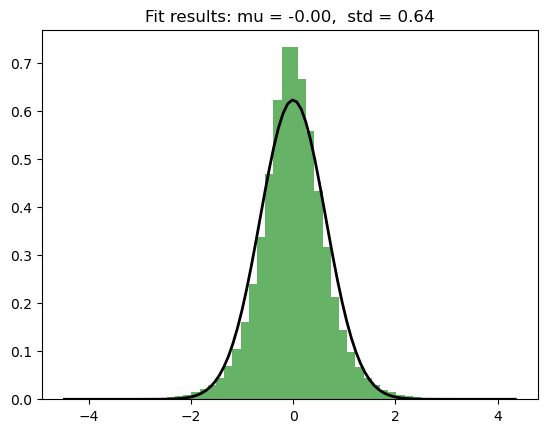

In [28]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [29]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [30]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [31]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [32]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5455148399933676

Classification Report:
               precision    recall  f1-score   support

         epi       0.81      0.58      0.68      4044
         imm       0.24      0.40      0.30       936
         str       0.36      0.53      0.43      1051

    accuracy                           0.55      6031
   macro avg       0.47      0.51      0.47      6031
weighted avg       0.64      0.55      0.58      6031



### AUC

In [34]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

AUC: 0.8091964143497761


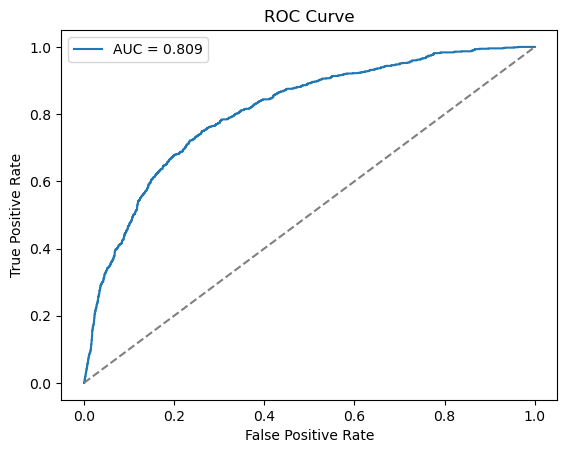

In [100]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="232_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [35]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.6918
Multiclass ROC AUC (OvR, weighted): 0.6966


# Map clusters to spatial 

In [59]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
c_3_154_37,7.284192,7.744848,1,1.000000,imm
c_3_154_43,6.756730,9.643015,0,0.752868,epi
c_3_154_61,3.038893,1.715372,-1,0.000000,epi
c_3_154_69,3.084451,1.321105,5,0.915297,epi
c_3_154_75,2.195687,0.487721,5,1.000000,epi
...,...,...,...,...,...
c_3_163_214,1.408516,6.290531,3,1.000000,imm
c_3_163_1843,2.205639,3.253726,-1,0.000000,imm
c_3_163_2575,1.612729,9.464395,3,1.000000,str
c_3_164_158,1.162243,8.078731,3,1.000000,imm


In [64]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 109538


In [65]:
lrdata.obs['Cluster'] = clusters.astype('category')

/scratch/jobs/37428477/ipykernel_251608/1180120996.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


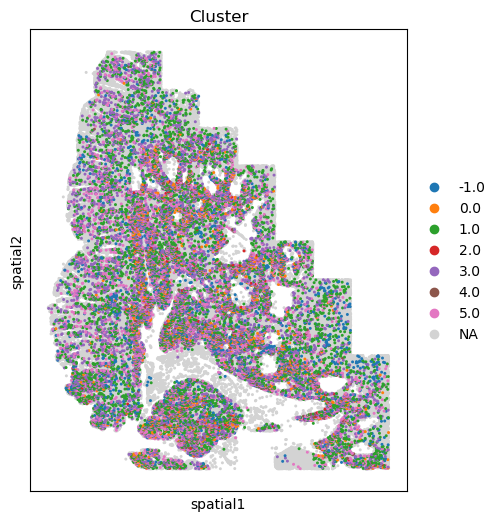

<Figure size 640x480 with 0 Axes>

In [70]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='Cluster',
    spot_size=40,
    ax=axes
)
plt.tight_layout()